# Results Visualization
Reads `Results_Tables_30runs.xlsx` directly. Produces the same 3 figures as original format.

**Output files:**
- `Table5_Win_Loss.png`
- `Table6_Green_Heatmap.png`
- `Table7_MFR_pre.png`

## Cell 1: Imports

In [3]:
import openpyxl
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

print("Imports OK")

Imports OK


## Cell 2: Load Excel + Compute Statistics

In [5]:
# =============================================================================
# Load Results_Tables_30runs.xlsx and compute statistics
# =============================================================================
wb = openpyxl.load_workbook('Results_Tables_30runs.xlsx', data_only=True)

def read_sheet(ws):
    headers = [c.value for c in next(ws.iter_rows(min_row=1, max_row=1))]
    methods = headers[3:]
    data = {}
    current_metric = None
    for row in ws.iter_rows(min_row=2, values_only=True):
        if row[0]: current_metric = row[0]
        ds = row[1]
        if not ds or not current_metric: continue
        if current_metric not in data: data[current_metric] = {}
        data[current_metric][ds] = {}
        for i, m in enumerate(methods):
            val = row[3+i]
            if val and isinstance(val, str) and '±' in val:
                try:
                    mean, std = val.split('±')
                    data[current_metric][ds][m] = float(mean)
                except: pass
            elif isinstance(val, (int, float)) and val is not None:
                data[current_metric][ds][m] = float(val)
    return data, methods

s1u, METHODS = read_sheet(wb['S1 Utility'])
s1f, _       = read_sheet(wb['S1 Fairness'])
s2u, _       = read_sheet(wb['S2 Utility'])
s2f, _       = read_sheet(wb['S2 Fairness'])

NON_KM = [m for m in METHODS if m != 'K-Means']
HIGHER = {'Silh. ↑','CHI ↑','BCSS ↑','V-Ratio ↑','Balance ↑','Entropy ↑'}
LOWER  = {'SSE ↓','DBI ↓','SPD ↓','|DI-1| ↓'}

def wins_vs_kmeans(data):
    wins = {m: 0 for m in NON_KM}
    for metric, ds_dict in data.items():
        for ds, mv in ds_dict.items():
            km = mv.get('K-Means')
            if km is None: continue
            for m in NON_KM:
                v = mv.get(m)
                if v is None: continue
                if (metric in HIGHER and v >= km) or (metric in LOWER and v <= km):
                    wins[m] += 1
    return wins

def best_score(data):
    best = {m: 0 for m in METHODS}
    for metric, ds_dict in data.items():
        for ds, mv in ds_dict.items():
            vals = {m: mv[m] for m in METHODS if m in mv}
            if not vals: continue
            # 找最优值
            best_val = max(vals.values()) if metric in HIGHER else min(vals.values())
            for m, v in vals.items():
                if abs(v - best_val) < 1e-9:
                    best[m] += 1
    return best

def mean_rank(data):
    """Mean fractional rank (1/7 = best, 7/7 = worst) — scaled to rank number 1-7"""
    ranks = {m: [] for m in METHODS}
    for metric, ds_dict in data.items():
        for ds, mv in ds_dict.items():
            vals = {m: mv[m] for m in METHODS if m in mv}
            if len(vals) < 2: continue
            sorted_m = sorted(vals, key=vals.get, reverse=(metric in HIGHER))
            for r, m in enumerate(sorted_m, 1):
                ranks[m].append(r)   # rank 1 = best, 7 = worst
    return {m: float(np.mean(v)) if v else np.nan for m, v in ranks.items()}

# Compute
w_s1u  = wins_vs_kmeans(s1u);  w_s1f  = wins_vs_kmeans(s1f)
w_s2u  = wins_vs_kmeans(s2u);  w_s2f  = wins_vs_kmeans(s2f)
bs_s1u = best_score(s1u);      bs_s1f = best_score(s1f)
bs_s2u = best_score(s2u);      bs_s2f = best_score(s2f)
mr_s1u = mean_rank(s1u);       mr_s1f = mean_rank(s1f)
mr_s2u = mean_rank(s2u);       mr_s2f = mean_rank(s2f)

print(f"Methods: {METHODS}")
print(f"Win vs KM (S1 Utility):  {w_s1u}")
print(f"Win vs KM (S1 Fairness): {w_s1f}")
print(f"Win vs KM (S2 Utility):  {w_s2u}")
print(f"Win vs KM (S2 Fairness): {w_s2f}")
print(f"Mean Rank S1U: {{{', '.join(f'{k}: {v:.2f}' for k,v in mr_s1u.items())}}}")
print(f"Mean Rank S1F: {{{', '.join(f'{k}: {v:.2f}' for k,v in mr_s1f.items())}}}")

Methods: ['K-Means', 'Fairlet', 'BFKM', 'CCF', 'PP-NFP', 'PP-Gini', 'Rawlsian']
Win vs KM (S1 Utility):  {'Fairlet': 1, 'BFKM': 22, 'CCF': 0, 'PP-NFP': 37, 'PP-Gini': 20, 'Rawlsian': 35}
Win vs KM (S1 Fairness): {'Fairlet': 47, 'BFKM': 39, 'CCF': 34, 'PP-NFP': 48, 'PP-Gini': 48, 'Rawlsian': 39}
Win vs KM (S2 Utility):  {'Fairlet': 1, 'BFKM': 27, 'CCF': 20, 'PP-NFP': 57, 'PP-Gini': 43, 'Rawlsian': 62}
Win vs KM (S2 Fairness): {'Fairlet': 47, 'BFKM': 43, 'CCF': 41, 'PP-NFP': 47, 'PP-Gini': 46, 'Rawlsian': 43}
Mean Rank S1U: {K-Means: 1.12, Fairlet: 6.94, BFKM: 4.41, CCF: 4.92, PP-NFP: 2.52, PP-Gini: 3.69, Rawlsian: 4.41}
Mean Rank S1F: {K-Means: 3.78, Fairlet: 3.04, BFKM: 4.14, CCF: 4.28, PP-NFP: 3.46, PP-Gini: 4.46, Rawlsian: 4.85}


## Cell 3: Figure 1 — Win-Loss vs K-Means

✓ Saved: Table5_Win_Loss.png


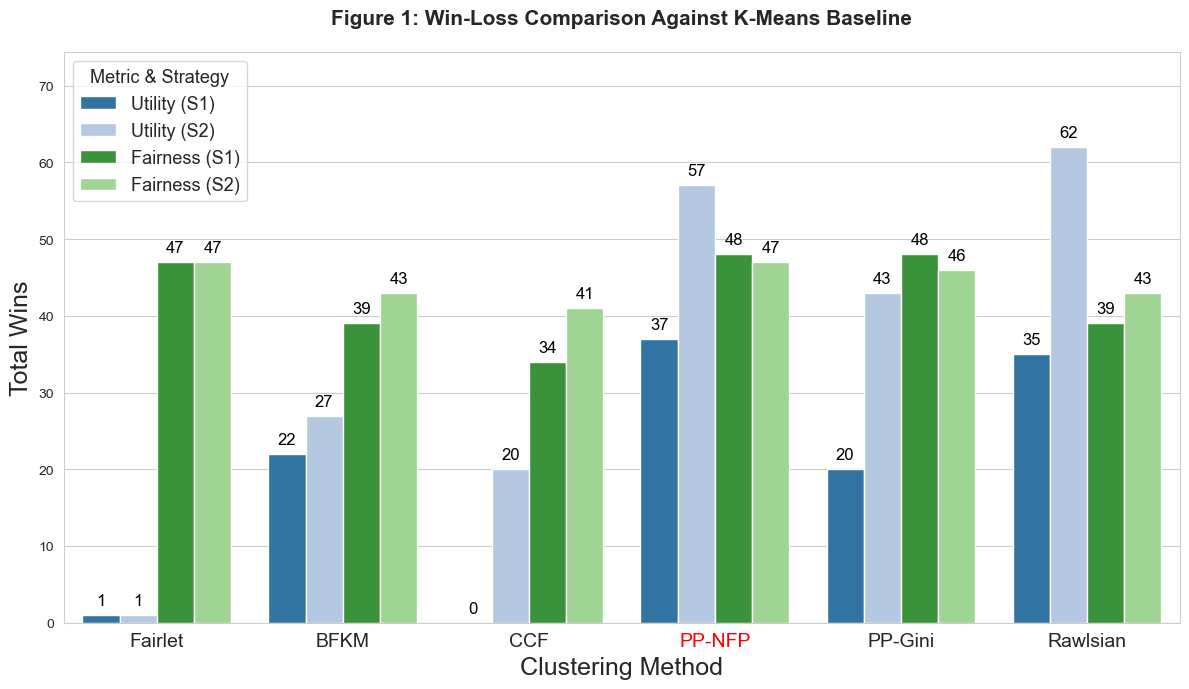

In [7]:
# =============================================================================
# Figure 1: Win-Loss Comparison Against K-Means Baseline
# (same format as original Table5_Win_Loss.png)
# =============================================================================

data = {
    'Method':        NON_KM,
    'Utility (S1)':  [w_s1u[m] for m in NON_KM],
    'Utility (S2)':  [w_s2u[m] for m in NON_KM],
    'Fairness (S1)': [w_s1f[m] for m in NON_KM],
    'Fairness (S2)': [w_s2f[m] for m in NON_KM],
}

df = pd.DataFrame(data).melt(id_vars='Method', var_name='Metric_Strategy', value_name='Wins')

plt.figure(figsize=(12, 7), dpi=100)
sns.set_style("whitegrid")

palette = {
    'Utility (S1)': '#1f77b4', 'Utility (S2)': '#aec7e8',
    'Fairness (S1)': '#2ca02c', 'Fairness (S2)': '#98df8a'
}

ax = sns.barplot(data=df, x='Method', y='Wins', hue='Metric_Strategy', palette=palette)

for label in ax.get_xticklabels():
    if label.get_text() == 'PP-NFP':
        label.set_color('red')
        label.set_fontsize(14)
    else:
        label.set_fontsize(14)

for container in ax.containers:
    labels = [f'{int(v.get_height())}' if v.get_height() >= 0 else '' for v in container]
    ax.bar_label(container, labels=labels, padding=5, fontsize=12, color='black')

plt.title('Figure 1: Win-Loss Comparison Against K-Means Baseline',
          fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Total Wins', fontsize=18)
plt.xlabel('Clustering Method', fontsize=18)

ax.set_ylim(0, df['Wins'].max() * 1.2)

plt.legend(title='Metric & Strategy',
           loc='upper left',
           fontsize=13,
           title_fontsize=13,
           frameon=True,
           framealpha=0.8,
           ncol=1)

plt.tight_layout()
plt.savefig('Table5_Win_Loss.png', dpi=150, bbox_inches='tight')
print("✓ Saved: Table5_Win_Loss.png")
plt.show()

## Cell 4: Figure 2 — Best-Score Heatmap

✓ Saved: Table6_Green_Heatmap.png


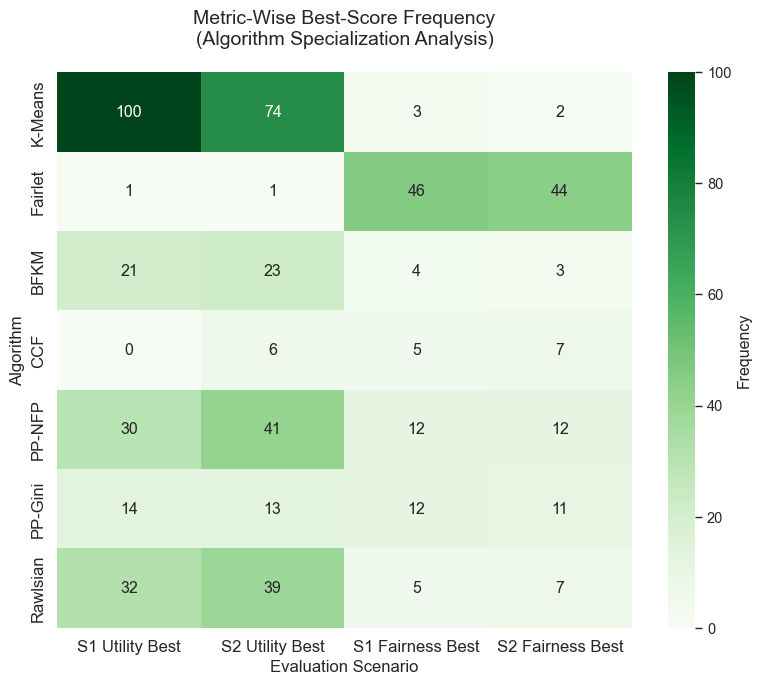

In [9]:
# =============================================================================
# Figure 2: Best-Score Frequency Heatmap
# (same format as original Table6_Green_Heatmap.png)
# =============================================================================

algorithms = METHODS
columns    = ['S1 Utility Best', 'S2 Utility Best', 'S1 Fairness Best', 'S2 Fairness Best']

scores = np.array([
    [bs_s1u[m], bs_s2u[m], bs_s1f[m], bs_s2f[m]]
    for m in algorithms
])

plt.figure(figsize=(8, 7))
sns.set_context("paper", font_scale=1.2)

ax = sns.heatmap(scores,
                 annot=True,
                 fmt="d",
                 cmap="Greens",
                 xticklabels=columns,
                 yticklabels=algorithms,
                 linewidths=0,
                 cbar_kws={'label': 'Frequency'})

ax.tick_params(axis='both', which='major', labelsize=12)

plt.title('Metric-Wise Best-Score Frequency\n(Algorithm Specialization Analysis)',
          fontsize=14, pad=20)
plt.xlabel('Evaluation Scenario', fontsize=12)
plt.ylabel('Algorithm', fontsize=12)

plt.tight_layout()
plt.savefig('Table6_Green_Heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: Table6_Green_Heatmap.png")
plt.show()

## Cell 5: Figure 3 — Performance Map

In [11]:
import openpyxl
import numpy as np
import pandas as pd

wb = openpyxl.load_workbook('Results_Tables_30runs.xlsx', data_only=True)

def read_sheet(ws):
    headers = [c.value for c in next(ws.iter_rows(min_row=1, max_row=1))]
    methods = headers[3:]
    data = {}
    current_metric = None
    for row in ws.iter_rows(min_row=2, values_only=True):
        if row[0]: current_metric = row[0]
        ds = row[1]
        if not ds or not current_metric: continue
        if current_metric not in data: data[current_metric] = {}
        data[current_metric][ds] = {}
        for i, m in enumerate(methods):
            val = row[3+i]
            if val and isinstance(val, str) and '±' in val:
                try:
                    data[current_metric][ds][m] = float(val.split('±')[0])
                except: pass
            elif isinstance(val, (int, float)) and val is not None:
                data[current_metric][ds][m] = float(val)
    return data, methods

s1u, METHODS = read_sheet(wb['S1 Utility'])
s1f, _       = read_sheet(wb['S1 Fairness'])
s2u, _       = read_sheet(wb['S2 Utility'])
s2f, _       = read_sheet(wb['S2 Fairness'])

HIGHER = {'Silh. ↑','CHI ↑','BCSS ↑','V-Ratio ↑','Balance ↑','Entropy ↑'}
LOWER  = {'SSE ↓','DBI ↓','SPD ↓','|DI-1| ↓'}

def compute_ranks(data, sheet_name):
    rows = []
    for metric, ds_dict in data.items():
        higher = metric in HIGHER
        for ds, mv in ds_dict.items():
            vals = {m: mv[m] for m in METHODS if m in mv}
            if not vals: continue

            # Sort: best first
            sorted_methods = sorted(
                vals.keys(),
                key=lambda m: -vals[m] if higher else vals[m]
            )

            # Standard average rank for all ties (K-Means treated same as others)
            ranks = {}
            i = 0
            while i < len(sorted_methods):
                m = sorted_methods[i]
                v = vals[m]
                # Find all methods with same value
                tie_group = [m2 for m2 in sorted_methods[i:]
                             if abs(vals[m2] - v) < 1e-9]
                n_tie = len(tie_group)
                # Average rank for all tied methods
                avg_rank = np.mean([i + j + 1 for j in range(n_tie)])
                for m2 in tie_group:
                    ranks[m2] = avg_rank
                i += n_tie

            row = {'Sheet': sheet_name, 'Metric': metric, 'Dataset': ds}
            for m in METHODS:
                row[m] = ranks.get(m, np.nan)
            rows.append(row)
    return rows


all_rows = []
for data, name in [(s1u,'S1 Utility'),(s1f,'S1 Fairness'),
                   (s2u,'S2 Utility'),(s2f,'S2 Fairness')]:
    all_rows.extend(compute_ranks(data, name))

rank_df = pd.DataFrame(all_rows)

# Mean rank per method per sheet
print("=== MEAN RANK PER METHOD PER SHEET (lower = better) ===")
for sheet in ['S1 Utility','S1 Fairness','S2 Utility','S2 Fairness']:
    sub = rank_df[rank_df['Sheet']==sheet]
    means = sub[METHODS].mean().round(3)
    print(f"\n{sheet}:")
    print(means.to_string())

# Overall mean rank (avg across all sheets)
print("\n=== OVERALL MEAN RANK (all metrics, all datasets, S1+S2) ===")
print(rank_df[METHODS].mean().round(3).to_string())

# Save full rank table
rank_df.to_csv('rank_table_all.csv', index=False)
print("\n✓ Saved: rank_table_all.csv")

# Pivot: mean rank per method per metric
print("\n=== MEAN RANK PER METRIC (across all datasets, S1+S2 combined) ===")
pivot = rank_df.groupby('Metric')[METHODS].mean().round(3)
print(pivot.to_string())
pivot.to_csv('rank_by_metric.csv')
print("✓ Saved: rank_by_metric.csv")

=== MEAN RANK PER METHOD PER SHEET (lower = better) ===

S1 Utility:
K-Means     1.593
Fairlet     6.944
BFKM        4.421
CCF         4.935
PP-NFP      2.500
PP-Gini     3.468
Rawlsian    4.139

S1 Fairness:
K-Means     4.160
Fairlet     3.042
BFKM        4.153
CCF         4.292
PP-NFP      3.868
PP-Gini     3.868
Rawlsian    4.618

S2 Utility:
K-Means     2.440
Fairlet     6.917
BFKM        4.352
CCF         4.731
PP-NFP      2.514
PP-Gini     3.403
Rawlsian    3.644

S2 Fairness:
K-Means     4.326
Fairlet     3.139
BFKM        4.069
CCF         4.146
PP-NFP      4.021
PP-Gini     4.049
Rawlsian    4.250

=== OVERALL MEAN RANK (all metrics, all datasets, S1+S2) ===
K-Means     2.907
Fairlet     5.394
BFKM        4.276
CCF         4.588
PP-NFP      3.082
PP-Gini     3.644
Rawlsian    4.108

✓ Saved: rank_table_all.csv

=== MEAN RANK PER METRIC (across all datasets, S1+S2 combined) ===
           K-Means  Fairlet   BFKM    CCF  PP-NFP  PP-Gini  Rawlsian
Metric                          

Fairness ranks: {'K-Means': 4.24, 'Fairlet': 3.09, 'BFKM': 4.11, 'CCF': 4.22, 'PP-NFP': 3.94, 'PP-Gini': 3.96, 'Rawlsian': 4.43}
Utility ranks:  {'K-Means': 2.02, 'Fairlet': 6.93, 'BFKM': 4.39, 'CCF': 4.83, 'PP-NFP': 2.51, 'PP-Gini': 3.44, 'Rawlsian': 3.89}
✓ Saved: Table7_MFR_pre.png


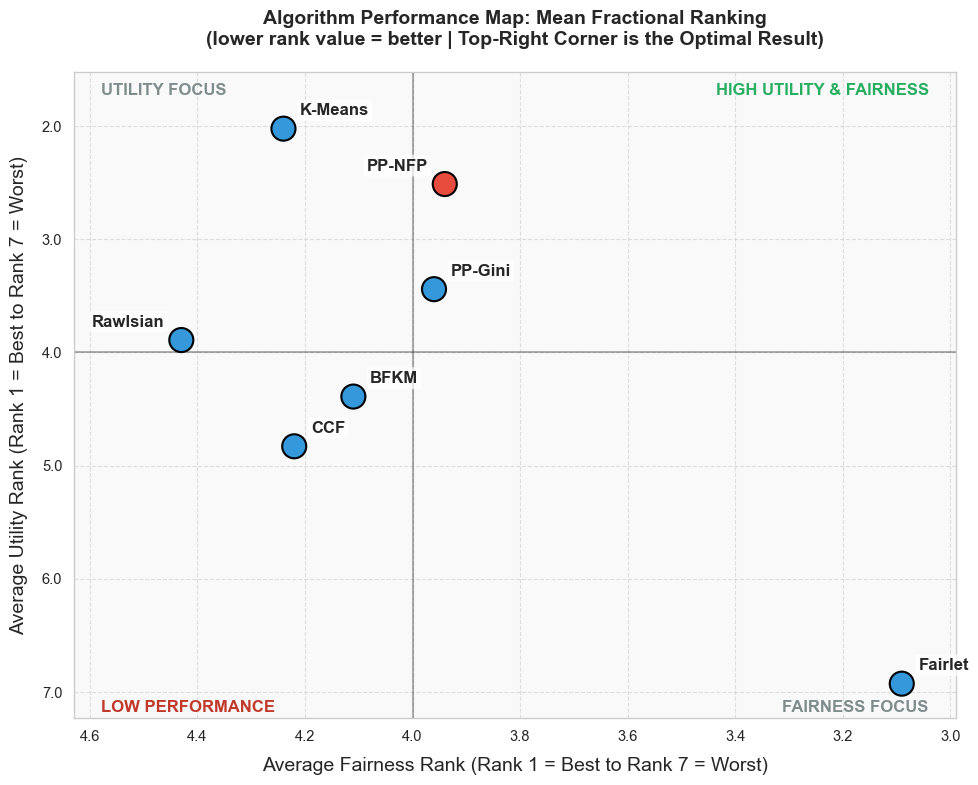

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# =============================================================================
# Figure 3: Algorithm Performance Map (from rank_by_metric.csv)
# =============================================================================

# Load rank data
rank_all = pd.read_csv('rank_table_all.csv', index_col=0)

UTIL_METRICS = ['SSE ↓', 'Silh. ↑', 'CHI ↑', 'DBI ↓', 'BCSS ↑', 'V-Ratio ↑']
FAIR_METRICS = ['Balance ↑', 'SPD ↓', '|DI-1| ↓', 'Entropy ↑']

# Compute mean rank for utility and fairness separately
util_ranks = rank_all[rank_all['Metric'].isin(UTIL_METRICS)][METHODS].mean()
fair_ranks = rank_all[rank_all['Metric'].isin(FAIR_METRICS)][METHODS].mean()

labels        = METHODS
fairness_rank = [round(fair_ranks[m], 2) for m in labels]
utility_rank  = [round(util_ranks[m], 2) for m in labels]

print("Fairness ranks:", dict(zip(labels, fairness_rank)))
print("Utility ranks: ", dict(zip(labels, utility_rank)))

plt.figure(figsize=(10, 8), dpi=100)
plt.rcParams['axes.facecolor'] = '#f9f9f9'
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)

colors = ['#e74c3c' if x == 'PP-NFP' else '#3498db' for x in labels]
plt.scatter(fairness_rank, utility_rank, s=300, c=colors,
            edgecolors='black', linewidth=1.5, zorder=3)

for i, txt in enumerate(labels):
    x_offset = 12
    align = 'left'
    if txt in ['PP-NFP', 'Rawlsian']:
        x_offset = -12
        align = 'right'
    plt.annotate(txt, (fairness_rank[i], utility_rank[i]),
                 xytext=(x_offset, 10),
                 textcoords='offset points',
                 fontsize=12, fontweight='bold', ha=align,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

# Axis limits: reversed so lower rank (better) = top-right
x_min = max(fairness_rank) + 0.2
x_max = min(fairness_rank) - 0.1
y_min = max(utility_rank)  + 0.3
y_max = min(utility_rank)  - 0.5
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

# Quadrant lines
plt.axvline(x=4, color='black', linestyle='-', linewidth=1.5, alpha=0.3)
plt.axhline(y=4, color='black', linestyle='-', linewidth=1.5, alpha=0.3)

# Quadrant labels
plt.text(x_max+0.05, y_max+0.2, "HIGH UTILITY & FAIRNESS",
         color='#27ae60', fontsize=12, fontweight='bold', ha='right')
plt.text(x_min-0.05, y_max+0.2, "UTILITY FOCUS",
         color='#7f8c8d', fontsize=12, fontweight='bold', ha='left')
plt.text(x_max+0.05, y_min-0.05, "FAIRNESS FOCUS",
         color='#7f8c8d', fontsize=12, fontweight='bold', ha='right')
plt.text(x_min-0.05, y_min-0.05, "LOW PERFORMANCE",
         color='#c0392b', fontsize=12, fontweight='bold', ha='left')

plt.title('Algorithm Performance Map: Mean Fractional Ranking\n'
          '(lower rank value = better | Top-Right Corner is the Optimal Result)',
          fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Average Fairness Rank (Rank 1 = Best to Rank 7 = Worst)', fontsize=14, labelpad=10)
plt.ylabel('Average Utility Rank (Rank 1 = Best to Rank 7 = Worst)', fontsize=14, labelpad=10)

ax = plt.gca()
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.savefig('Table7_MFR_pre.png', dpi=150, bbox_inches='tight')
print("✓ Saved: Table7_MFR_pre.png")
plt.show()